<div style='display:flex; align-items:center; justify-content:space-between; border-bottom: 3px solid rgb(255,106,0); padding-bottom:1em; margin-bottom:1em'>
<div>
<span style='color:rgb(22,60,105); font-size:1.8em; font-weight:bold;'>Introduction to Deep Learning</span><br>
<span style='color:rgb(0,85,100); font-size:1.3em;'>Session 12 &mdash; Variational Autoencoders</span><br>
<span style='color:rgb(0,85,100); font-size:1.0em;'>Magda Gregorová &nbsp;·&nbsp; THWS &nbsp;·&nbsp; July 2026</span>
</div>
<img src='../../Common/Pics/thws-logo_vert_en_orange-rgb.png' style='height:80px;'/>
</div>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import pandas as pd
from torch.utils.data import DataLoader, Subset

from models import AE, VAE
from training import train_model, train_probe, evaluate_reconstruction
from helpers import (
    plot_data_examples,
    plot_losses,
    plot_vae_losses,
    plot_examples_with_codes,
    plot_latent_scatter_ae,
    plot_latent_scatter_vae,
    plot_samples_grid,
    plot_interpolation,
    plot_pixel_histogram,
    plot_reconstructions,
    plot_probe_accuracies,
    encode_dataset,
)

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>MNIST data</strong>
</div>

28x28 grayscale handwritten digits, pixel values normalized to [0,1]

In [3]:
# Download MNIST, pixels in [0,1]
transform = transforms.ToTensor()
train_dataset = torchvision.datasets.MNIST(root='../../data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='../../data', train=False, download=True, transform=transform)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 60000
Test set size: 10000


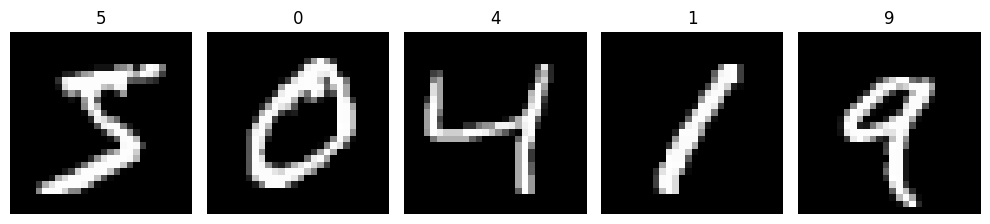

In [4]:
# display examples
plot_data_examples(train_dataset)

In [5]:
# data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Plain autoencoder baseline</strong>
</div>

Small CNN encoder/decoder, 2D bottleneck, L2 reconstruction loss

In [6]:
# basic setup
model_ae = AE(latent_dim=2).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(model_ae.parameters(), lr=1e-3)
num_epochs = 30

In [7]:
# train model
model_ae, ae_train_losses, ae_recon_losses, ae_kl_losses = train_model(
    model_ae, train_loader, criterion, optimizer, num_epochs, device, is_vae=False
)

Epoch 1: loss=60.0066, recon=60.0066, kl=0.0000
Epoch 2: loss=44.1494, recon=44.1494, kl=0.0000
Epoch 3: loss=42.4512, recon=42.4512, kl=0.0000
Epoch 4: loss=41.5936, recon=41.5936, kl=0.0000
Epoch 5: loss=41.0050, recon=41.0050, kl=0.0000
Epoch 6: loss=40.5177, recon=40.5177, kl=0.0000
Epoch 7: loss=40.0169, recon=40.0169, kl=0.0000
Epoch 8: loss=39.5970, recon=39.5970, kl=0.0000
Epoch 9: loss=39.2302, recon=39.2302, kl=0.0000
Epoch 10: loss=38.9084, recon=38.9084, kl=0.0000
Epoch 11: loss=38.5937, recon=38.5937, kl=0.0000
Epoch 12: loss=38.2867, recon=38.2867, kl=0.0000
Epoch 13: loss=38.0057, recon=38.0057, kl=0.0000
Epoch 14: loss=37.7462, recon=37.7462, kl=0.0000
Epoch 15: loss=37.5077, recon=37.5077, kl=0.0000
Epoch 16: loss=37.3070, recon=37.3070, kl=0.0000
Epoch 17: loss=37.1103, recon=37.1103, kl=0.0000
Epoch 18: loss=36.9264, recon=36.9264, kl=0.0000
Epoch 19: loss=36.7283, recon=36.7283, kl=0.0000
Epoch 20: loss=36.5609, recon=36.5609, kl=0.0000
Epoch 21: loss=36.4282, recon

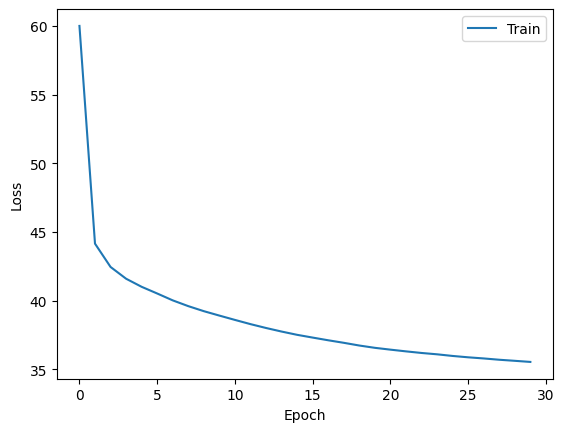

In [8]:
# plot loss
plot_losses(ae_train_losses)

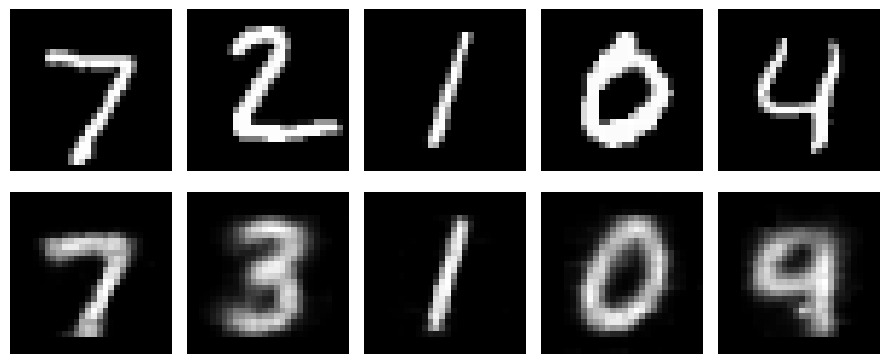

In [9]:
# reconstructions on test data
plot_reconstructions(model_ae, test_dataset, device, [0, 1, 2, 3, 4], is_vae=False)

In [10]:
# reconstruction error on test data
ae_test_recon = evaluate_reconstruction(model_ae, test_loader, criterion, device, is_vae=False)
print(f"AE test reconstruction error: {ae_test_recon:.4f}")

AE test reconstruction error: 35.3516


What is this '2D latent code' we keep talking about? Just two numbers per image:

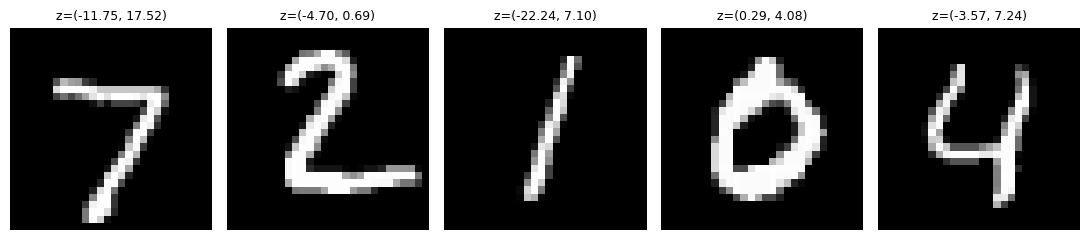

In [11]:
# a few examples with their learned 2D code
plot_examples_with_codes(model_ae, test_dataset, device)

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>The latent space problem</strong>
</div>

Where do all the test images end up in the 2D latent space?

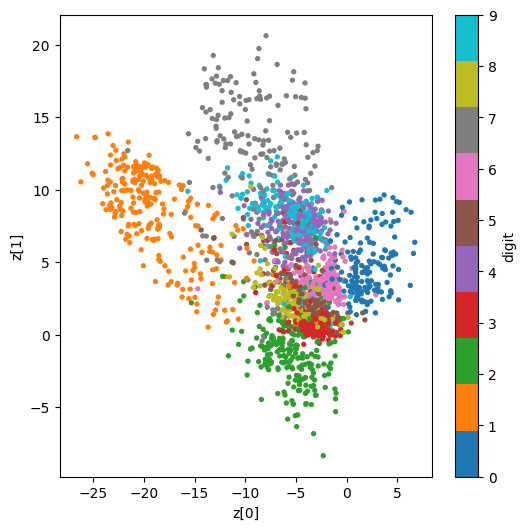

In [12]:
# scatter of latent codes, colored by digit
plot_latent_scatter_ae(model_ae, test_dataset, device)

The space is lumpy, with gaps and stray regions. What happens if we just pick a random point and decode it?

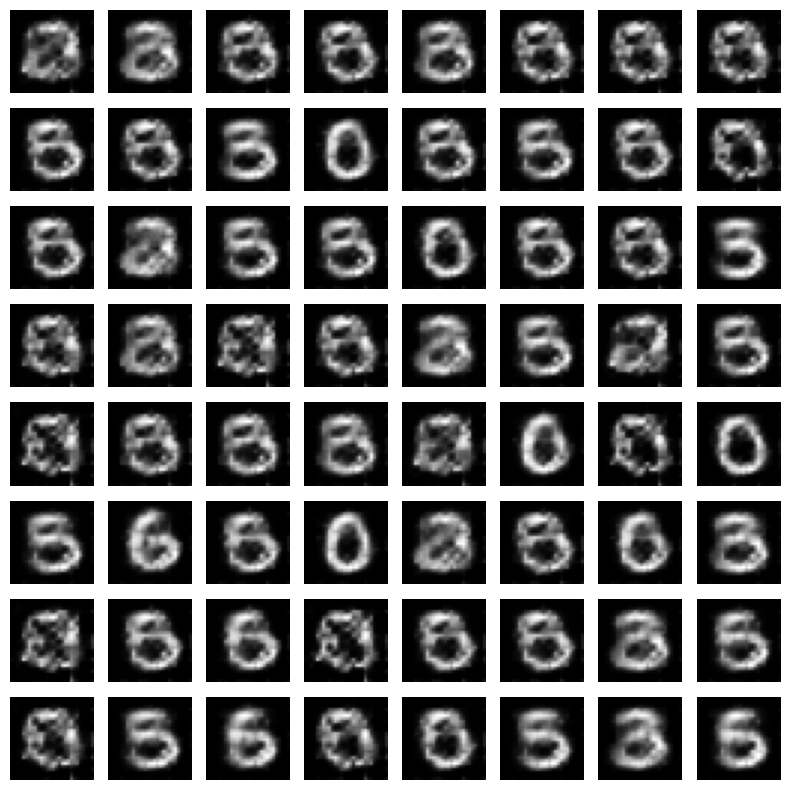

In [13]:
# sample z ~ N(0,I) and decode -- this is what 'generating' would mean
plot_samples_grid(model_ae, device)

Not digits. The autoencoder was never asked to make its latent space *fillable* -- it only had to reconstruct the training images, so it crammed them in however was convenient.

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>From autoencoder to variational autoencoder</strong>
</div>

To be able to sample meaningfully, we need the latent space to look like something we know how to sample from -- e.g. a standard normal $\mathcal{N}(0,I)$ -- and to vary smoothly so that nearby points decode to similar images.

The variational autoencoder changes two things:

- the encoder no longer outputs a single point $z$, but a distribution $q(z\mid x) = \mathcal{N}(\mu(x), \sigma^2(x))$
- the loss gets an extra term, $D_{KL}(q(z\mid x) \,\|\, \mathcal{N}(0,I))$, pulling every image's posterior toward the standard normal prior

To keep gradients flowing through the sampling step, we use the **reparameterization trick**: instead of sampling $z \sim \mathcal{N}(\mu, \sigma^2)$ directly, we sample $\epsilon \sim \mathcal{N}(0,I)$ and compute $z = \mu + \sigma \odot \epsilon$. Now the randomness sits in $\epsilon$, and $\mu, \sigma$ remain differentiable.

The full training objective (the negative ELBO) is:

$$\mathcal{L} = \underbrace{-\mathbb{E}_{q(z|x)}\big[\log p(x\mid z)\big]}_{\text{reconstruction}} + \underbrace{D_{KL}\big(q(z\mid x)\,\|\,\mathcal{N}(0,I)\big)}_{\text{regularization}}

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Training the VAE</strong>
</div>

Same CNN backbone as the AE -- literally the same `Encoder`/`Decoder` classes -- but the encoder now outputs $\mu$ and $\log\sigma^2$. Reconstruction loss stays L2 for now.

In [14]:
# basic setup
model_vae = VAE(latent_dim=2).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(model_vae.parameters(), lr=1e-3)
num_epochs = 30

In [15]:
# train model (L2 reconstruction + KL)
model_vae, vae_train_losses, vae_recon_losses, vae_kl_losses = train_model(
    model_vae, train_loader, criterion, optimizer, num_epochs, device, is_vae=True
)

Epoch 1: loss=63.4246, recon=59.8311, kl=3.5935
Epoch 2: loss=46.5370, recon=43.3471, kl=3.1900
Epoch 3: loss=43.7665, recon=40.4720, kl=3.2944
Epoch 4: loss=42.6062, recon=39.2086, kl=3.3977
Epoch 5: loss=41.9330, recon=38.4294, kl=3.5036
Epoch 6: loss=41.4480, recon=37.8501, kl=3.5980
Epoch 7: loss=41.1059, recon=37.4303, kl=3.6756
Epoch 8: loss=40.8561, recon=37.1141, kl=3.7420
Epoch 9: loss=40.6200, recon=36.8214, kl=3.7986
Epoch 10: loss=40.4353, recon=36.5834, kl=3.8519
Epoch 11: loss=40.2660, recon=36.3767, kl=3.8894
Epoch 12: loss=40.1105, recon=36.1636, kl=3.9469
Epoch 13: loss=39.9860, recon=36.0015, kl=3.9845
Epoch 14: loss=39.8541, recon=35.8319, kl=4.0222
Epoch 15: loss=39.7655, recon=35.7078, kl=4.0577
Epoch 16: loss=39.6541, recon=35.5650, kl=4.0891
Epoch 17: loss=39.5791, recon=35.4680, kl=4.1111
Epoch 18: loss=39.5196, recon=35.3733, kl=4.1463
Epoch 19: loss=39.4308, recon=35.2757, kl=4.1551
Epoch 20: loss=39.3793, recon=35.1954, kl=4.1838
Epoch 21: loss=39.3201, recon

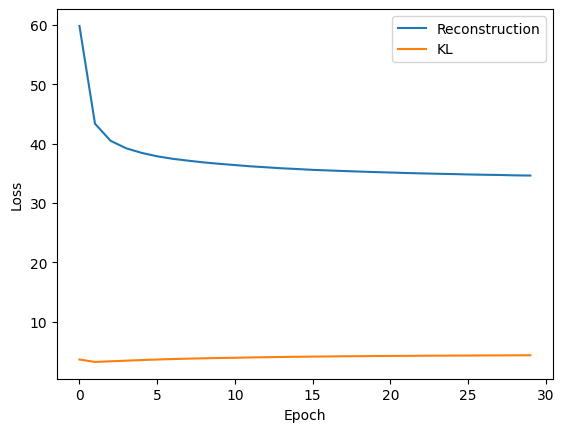

In [16]:
# plot the two loss components separately
plot_vae_losses(vae_recon_losses, vae_kl_losses)

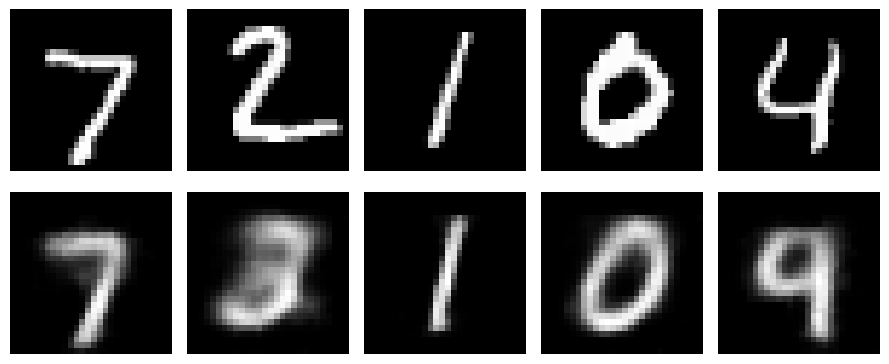

In [17]:
# reconstructions on test data
plot_reconstructions(model_vae, test_dataset, device, [0, 1, 2, 3, 4], is_vae=True)

In [18]:
# reconstruction error on test data
vae_test_recon = evaluate_reconstruction(model_vae, test_loader, criterion, device, is_vae=True)
print(f"VAE (L2) test reconstruction error: {vae_test_recon:.4f}")

VAE (L2) test reconstruction error: 34.4329


<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Latent space of the VAE</strong>
</div>

Same scatter plot as before -- scroll back up to compare with the plain autoencoder

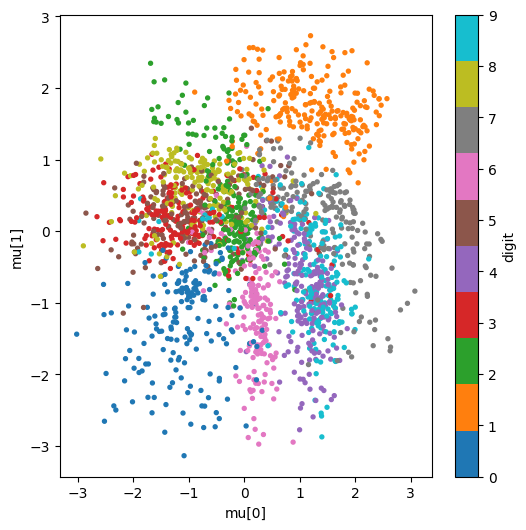

In [19]:
# scatter of latent means, colored by digit
plot_latent_scatter_vae(model_vae, test_dataset, device)

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Generating new digits</strong>
</div>

Now we sample $z \sim \mathcal{N}(0,I)$ again, on the model that was actually trained to make this space meaningful

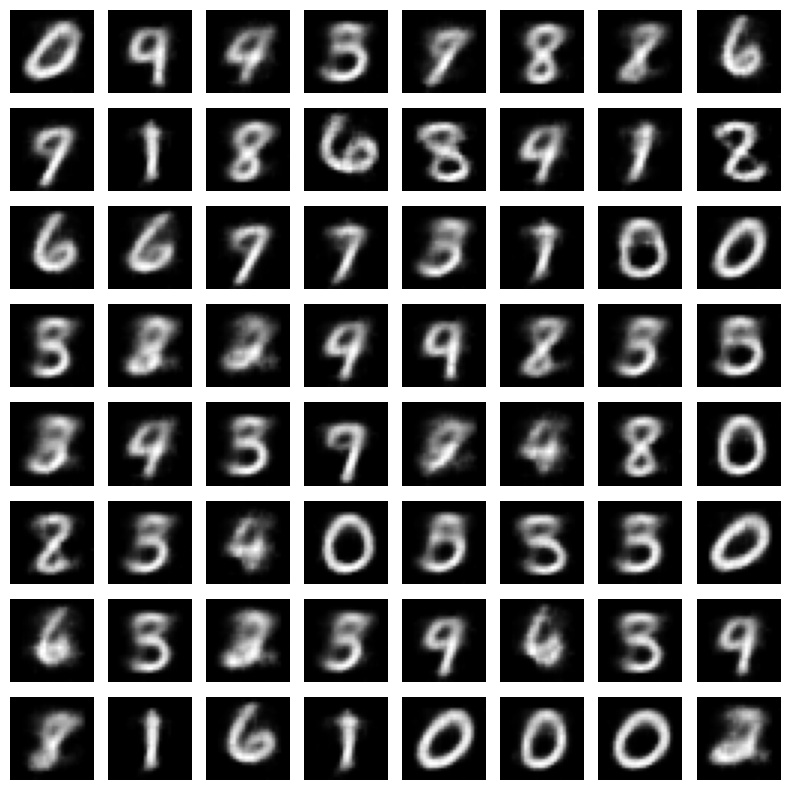

In [20]:
# sample and decode
plot_samples_grid(model_vae, device)

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Latent space interpolation</strong>
</div>

Pick two test digits, linearly interpolate between their latent codes, decode the path. Each frame is labeled with the $(z_0, z_1)$ that produced it.

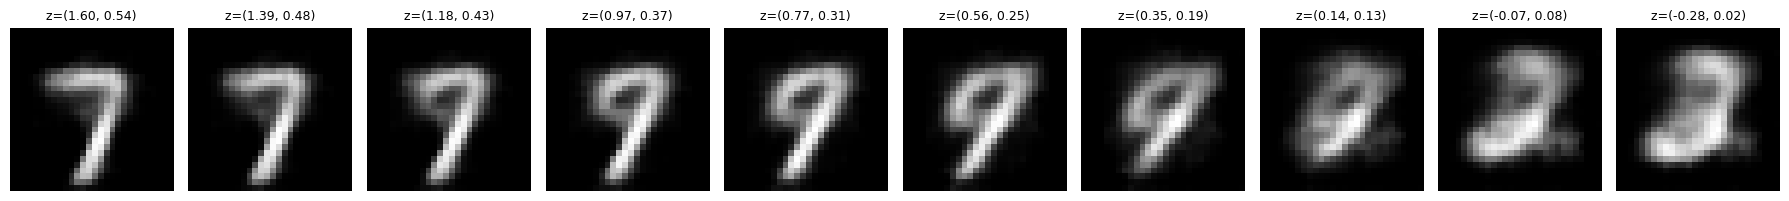

In [21]:
# interpolate between two digits
plot_interpolation(model_vae, test_dataset, device, idx1=0, idx2=1, is_vae=True)

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Wait a second...</strong>
</div>

We assumed a Gaussian likelihood (L2 loss) for the pixels without really checking it. What does the pixel value distribution actually look like?

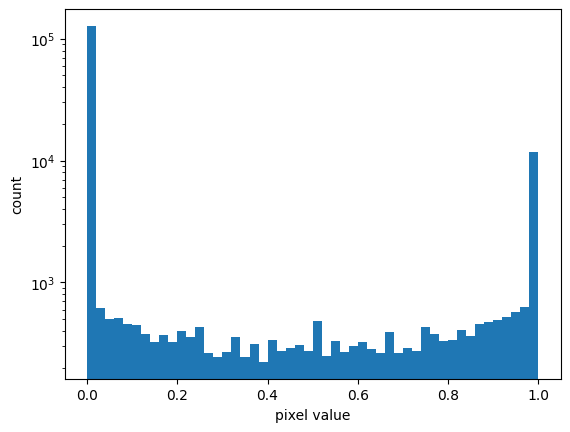

In [22]:
# pixel value histogram
plot_pixel_histogram(train_dataset)

Pixels pile up near 0 and near 1 -- 'ink' or 'no ink'. What if we push this all the way, and treat the images as strictly **black and white**?

From a probability perspective, this matters a lot. The reconstruction loss is really just $-\log p_\theta(x\mid z)$, and the likelihood we assume determines the loss:

- **Gaussian likelihood $\Rightarrow$ L2 loss.** A Gaussian has support on all of $\mathbb{R}$ -- it can assign probability to any real value. For data that only ever takes the values $0$ or $1$, this is the wrong tool: the squared-error-optimal prediction under uncertainty is the *average* of the plausible values, not a commitment to one of them. So a pixel the model is unsure about gets predicted as a wishy-washy grey, not a confident black or white.
- **Bernoulli likelihood $\Rightarrow$ binary cross-entropy (BCE) loss.** A Bernoulli distribution has support exactly on $\{0, 1\}$ -- a perfect match for binary pixels. The decoder's sigmoid output is interpreted as $p(\text{pixel}=1)$, and BCE is exactly $-\log p_\theta(x\mid z)$ under that model.

Let's binarize MNIST and check this empirically: train the same architecture with L2, then with BCE, on the same binary data.

In [23]:
# binarize: threshold each pixel at 0.5
binary_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float()),
])
train_dataset_bin = torchvision.datasets.MNIST(root='../../data', train=True, download=True, transform=binary_transform)
test_dataset_bin = torchvision.datasets.MNIST(root='../../data', train=False, download=True, transform=binary_transform)
train_loader_bin = DataLoader(train_dataset_bin, batch_size=128, shuffle=True)
test_loader_bin = DataLoader(test_dataset_bin, batch_size=128, shuffle=False)

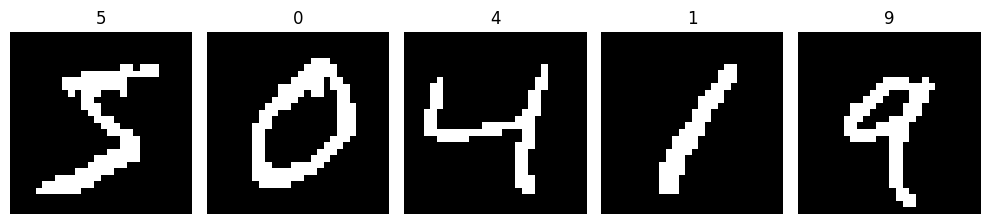

In [24]:
# a few binarized examples
plot_data_examples(train_dataset_bin)

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>L2 on binarized digits</strong>
</div>

Same architecture, same training setup -- only the data changed, loss assumption stays at L2

In [25]:
# basic setup
model_l2_bin = VAE(latent_dim=2).to(device)
criterion = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(model_l2_bin.parameters(), lr=1e-3)
num_epochs = 30

In [26]:
# train model (L2 reconstruction + KL, on binarized data)
model_l2_bin, l2bin_train_losses, l2bin_recon_losses, l2bin_kl_losses = train_model(
    model_l2_bin, train_loader_bin, criterion, optimizer, num_epochs, device, is_vae=True
)

Epoch 1: loss=76.5154, recon=73.3714, kl=3.1440
Epoch 2: loss=60.2184, recon=56.9164, kl=3.3020
Epoch 3: loss=57.5992, recon=54.1140, kl=3.4852
Epoch 4: loss=56.5638, recon=53.0228, kl=3.5410
Epoch 5: loss=55.9337, recon=52.3286, kl=3.6051
Epoch 6: loss=55.4875, recon=51.8229, kl=3.6646
Epoch 7: loss=55.1498, recon=51.4241, kl=3.7257
Epoch 8: loss=54.8761, recon=51.0848, kl=3.7914
Epoch 9: loss=54.6216, recon=50.7803, kl=3.8412
Epoch 10: loss=54.4475, recon=50.5501, kl=3.8973
Epoch 11: loss=54.2885, recon=50.3552, kl=3.9333
Epoch 12: loss=54.1313, recon=50.1618, kl=3.9696
Epoch 13: loss=54.0182, recon=49.9855, kl=4.0327
Epoch 14: loss=53.8823, recon=49.8238, kl=4.0585
Epoch 15: loss=53.7619, recon=49.6701, kl=4.0919
Epoch 16: loss=53.6623, recon=49.5495, kl=4.1128
Epoch 17: loss=53.5627, recon=49.4349, kl=4.1278
Epoch 18: loss=53.5068, recon=49.3433, kl=4.1636
Epoch 19: loss=53.4209, recon=49.2368, kl=4.1840
Epoch 20: loss=53.3650, recon=49.1652, kl=4.1998
Epoch 21: loss=53.3048, recon

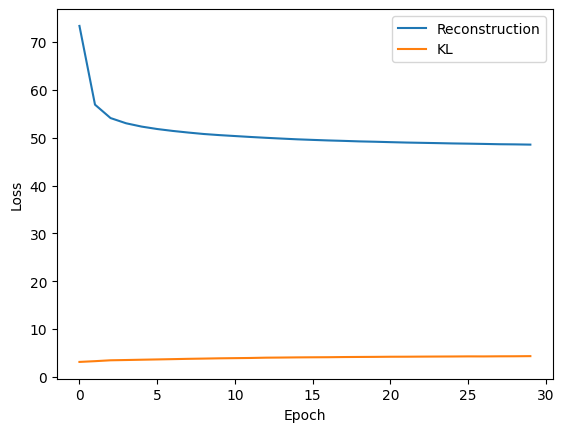

In [27]:
# plot the two loss components
plot_vae_losses(l2bin_recon_losses, l2bin_kl_losses)

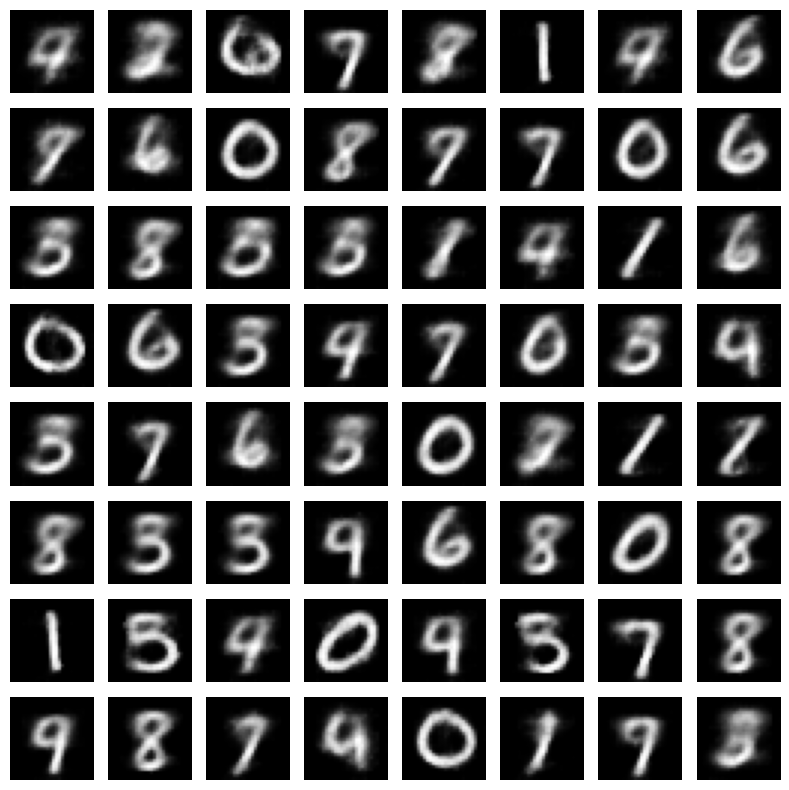

In [28]:
# sample and decode
plot_samples_grid(model_l2_bin, device)

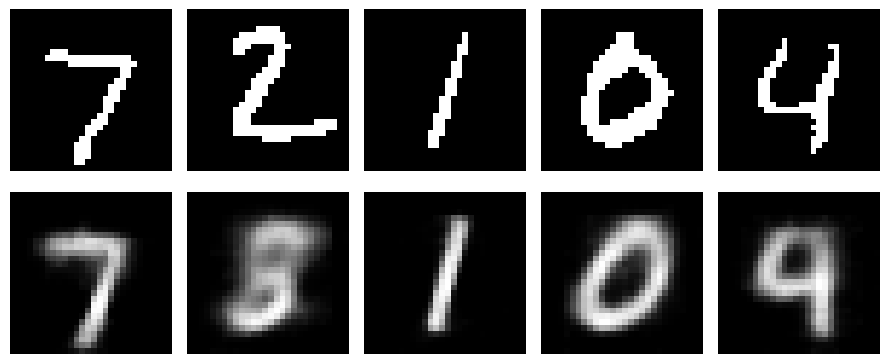

In [29]:
# reconstructions
plot_reconstructions(model_l2_bin, test_dataset_bin, device, [0, 1, 2, 3, 4], is_vae=True)

In [30]:
# reconstruction error on test data
l2bin_test_recon = evaluate_reconstruction(model_l2_bin, test_loader_bin, criterion, device, is_vae=True)
print(f"L2 (binary) test reconstruction error: {l2bin_test_recon:.4f}")

L2 (binary) test reconstruction error: 48.4878


Blurry, grey digits -- exactly the failure mode the probability argument predicted: L2 can't commit to black or white.

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>BCE on binarized digits</strong>
</div>

Same architecture again, this time matching loss to data: BCE on the binary pixels

In [31]:
# basic setup
model_bce_bin = VAE(latent_dim=2).to(device)
criterion = nn.BCELoss(reduction='sum')
optimizer = optim.Adam(model_bce_bin.parameters(), lr=1e-3)
num_epochs = 30

In [32]:
# train model (BCE reconstruction + KL, on binarized data)
model_bce_bin, bcebin_train_losses, bcebin_recon_losses, bcebin_kl_losses = train_model(
    model_bce_bin, train_loader_bin, criterion, optimizer, num_epochs, device, is_vae=True
)

Epoch 1: loss=228.2958, recon=220.2844, kl=8.0115
Epoch 2: loss=178.7496, recon=173.4146, kl=5.3349
Epoch 3: loss=171.7217, recon=166.5865, kl=5.1353
Epoch 4: loss=167.8091, recon=162.6634, kl=5.1457
Epoch 5: loss=165.0431, recon=159.8130, kl=5.2301
Epoch 6: loss=162.8669, recon=157.5438, kl=5.3232
Epoch 7: loss=161.1703, recon=155.7358, kl=5.4345
Epoch 8: loss=159.7773, recon=154.2887, kl=5.4886
Epoch 9: loss=158.8527, recon=153.2920, kl=5.5606
Epoch 10: loss=157.9905, recon=152.4009, kl=5.5895
Epoch 11: loss=157.3265, recon=151.7049, kl=5.6217
Epoch 12: loss=156.8550, recon=151.1916, kl=5.6634
Epoch 13: loss=156.3730, recon=150.6758, kl=5.6972
Epoch 14: loss=155.8932, recon=150.1797, kl=5.7135
Epoch 15: loss=155.5829, recon=149.8451, kl=5.7378
Epoch 16: loss=155.2860, recon=149.5458, kl=5.7402
Epoch 17: loss=154.9307, recon=149.1612, kl=5.7695
Epoch 18: loss=154.6668, recon=148.8904, kl=5.7764
Epoch 19: loss=154.4108, recon=148.6186, kl=5.7922
Epoch 20: loss=154.2322, recon=148.4347,

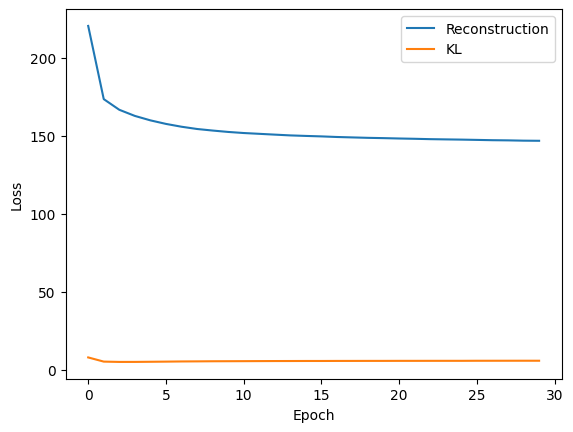

In [33]:
# plot the two loss components
plot_vae_losses(bcebin_recon_losses, bcebin_kl_losses)

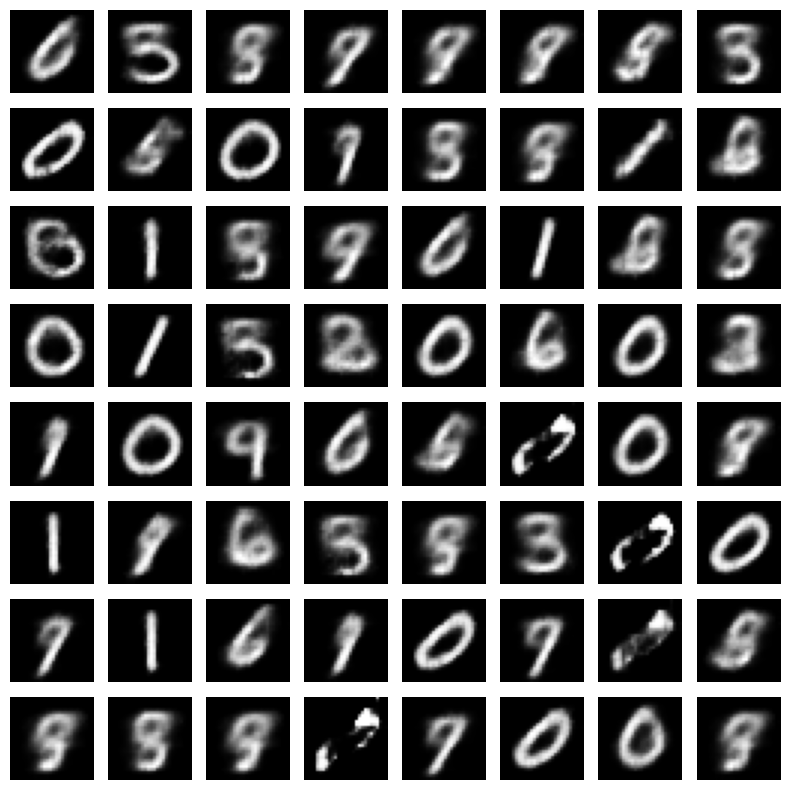

In [34]:
# sample and decode -- compare with the L2-on-binary samples above
plot_samples_grid(model_bce_bin, device)

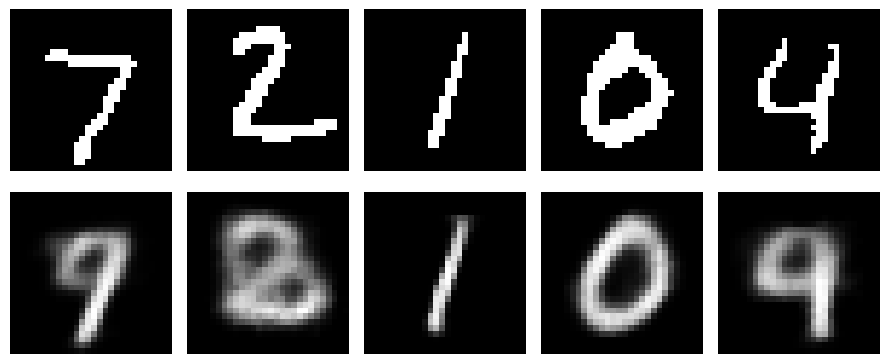

In [35]:
# reconstructions -- compare with the L2-on-binary reconstructions above
plot_reconstructions(model_bce_bin, test_dataset_bin, device, [0, 1, 2, 3, 4], is_vae=True)

In [36]:
# reconstruction error on test data
bcebin_test_recon = evaluate_reconstruction(model_bce_bin, test_loader_bin, criterion, device, is_vae=True)
print(f"BCE (binary) test reconstruction error: {bcebin_test_recon:.4f}")

BCE (binary) test reconstruction error: 147.3130


Crisp, confident black-and-white digits. Same network, same data, same training budget -- the only thing that changed is matching the loss to the actual likelihood of the data, exactly the ELBO's reconstruction term as derived in lecture.

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Summary: reconstruction error on test data</strong>
</div>

One number per model, all computed on held-out test data using each model's own training loss. Note the L2 and BCE rows are **not directly comparable to each other** -- they are different quantities on different scales, exactly as we discussed earlier. Within a loss type, though, lower is better.

In [37]:
# summary table
summary = pd.DataFrame({
    'model': ['AE', 'VAE', 'L2 (binary)', 'BCE (binary)'],
    'loss': ['L2', 'L2', 'L2', 'BCE'],
    'test reconstruction error': [ae_test_recon, vae_test_recon, l2bin_test_recon, bcebin_test_recon],
})
summary

,model,loss,test reconstruction error
0,AE,L2,35.351595
1,VAE,L2,34.432928
2,L2 (binary),L2,48.487773
3,BCE (binary),BCE,147.313034


<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Are the latent codes useful for classification?</strong>
</div>

Every model above was trained without ever seeing a digit label -- purely to reconstruct images. How much information about the digit *class* ended up in just two latent numbers anyway?

We'll probe this with the simplest possible classifier: a single linear layer (logistic regression) trained on top of the frozen latent codes from each model. To really showcase what the representation has already captured, we deliberately starve the probe of labels: it only gets to train on a small **random subset of 500 images** (out of 60,000), and is then evaluated on the full test set. If two unsupervised numbers per image already carry strong class information, a linear classifier should still do reasonably well even with almost no labeled data -- that's the power of representation learning: the hard work happened before the probe ever saw a single label.

In [38]:
# small random subset of labeled training data for the probe
torch.manual_seed(0)
probe_indices = torch.randperm(len(train_dataset))[:500]
probe_train_dataset = Subset(train_dataset, probe_indices)
probe_train_dataset_bin = Subset(train_dataset_bin, probe_indices)

In [39]:
# encode the small probe-training subset and the full test set into latent codes, for each of the four models
z_train_ae, y_train = encode_dataset(model_ae, probe_train_dataset, device, is_vae=False)
z_test_ae, y_test = encode_dataset(model_ae, test_dataset, device, is_vae=False)

z_train_vae, _ = encode_dataset(model_vae, probe_train_dataset, device, is_vae=True)
z_test_vae, _ = encode_dataset(model_vae, test_dataset, device, is_vae=True)

z_train_l2bin, y_train_bin = encode_dataset(model_l2_bin, probe_train_dataset_bin, device, is_vae=True)
z_test_l2bin, y_test_bin = encode_dataset(model_l2_bin, test_dataset_bin, device, is_vae=True)

z_train_bcebin, _ = encode_dataset(model_bce_bin, probe_train_dataset_bin, device, is_vae=True)
z_test_bcebin, _ = encode_dataset(model_bce_bin, test_dataset_bin, device, is_vae=True)

In [40]:
# train a linear probe on each representation
_, acc_ae = train_probe(z_train_ae, y_train, z_test_ae, y_test, num_epochs=200, device=device)
_, acc_vae = train_probe(z_train_vae, y_train, z_test_vae, y_test, num_epochs=200, device=device)
_, acc_l2bin = train_probe(z_train_l2bin, y_train_bin, z_test_l2bin, y_test_bin, num_epochs=200, device=device)
_, acc_bcebin = train_probe(z_train_bcebin, y_train_bin, z_test_bcebin, y_test_bin, num_epochs=200, device=device)

print(f"AE:            {acc_ae:.3f}")
print(f"VAE:           {acc_vae:.3f}")
print(f"L2 on binary:  {acc_l2bin:.3f}")
print(f"BCE on binary: {acc_bcebin:.3f}")

AE:            0.676
VAE:           0.594
L2 on binary:  0.589
BCE on binary: 0.576


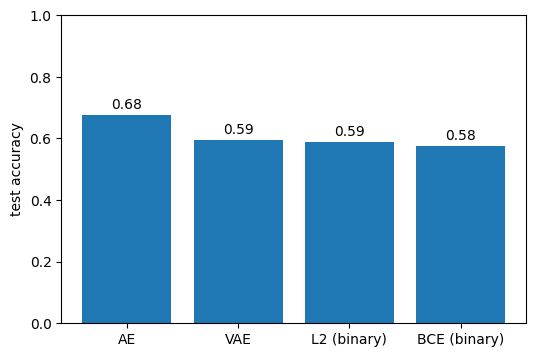

In [41]:
# compare
plot_probe_accuracies(
    ['AE', 'VAE', 'L2 (binary)', 'BCE (binary)'],
    [acc_ae, acc_vae, acc_l2bin, acc_bcebin]
)

Two numbers per image, learned with no labels at all, already carry a surprising amount of class information -- and how much depends on how well-structured the latent space is, which is exactly what we were looking at visually in the scatter plots throughout this notebook.

<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Exercise: should we quantize the binary VAE's output?</strong>
</div>

One more thing worth thinking about, which we'll leave as an exercise rather than solve here.

The decoder of `model_l2_bin` and `model_bce_bin` outputs a sigmoid value per pixel -- that is the Bernoulli parameter $p(\text{pixel}=1)$, **not** a sample of the pixel itself. Every sample/reconstruction plot in the previous section showed this raw probability map directly, which is why the images still look grayscale even though the underlying data and the model's likelihood are both binary.

Two natural ways to turn that probability map into an actual black-and-white image:

- **Threshold at 0.5**: `(p > 0.5).float()` -- a simple, deterministic decision rule.
- **Sample from the Bernoulli**: treat each pixel's $p$ as a literal probability and draw a $\{0,1\}$ outcome per pixel -- a genuine sample from what the model defines as the data distribution.

Try implementing both for `model_l2_bin` and `model_bce_bin`, and compare:

- What happens to the BCE model's output? (Given it already predicts confident probabilities, how much do you expect either method to change the image?)
- What happens to the L2 model's output? Thresholding a blurry, grey prediction does not recover a clean digit -- what does it look like instead, and why? Does sampling behave differently than thresholding here?
- Which of the two quantization methods is the "correct" one if we want to claim we are generating a sample *from the model*, rather than just visualizing its most likely guess per pixel?